**IMPORT FILE**

Tanpa mounting drive pakai URL saja

In [ ]:
import pandas as pd #library untuk memproses data
import seaborn as sns #library plot
import matplotlib.pyplot as plt #library plot
import numpy as np #proses matematika
from sklearn.preprocessing import PowerTransformer #Transformasi data
from google.colab import files #Memproses file

In [ ]:
url = "https://drive.google.com/uc?export=download&id=11BxHPSTTXOb_xRiQoSSR0o_4qzxEyped"
df = pd.read_csv(url, sep = ";") #URL dibaca

Baca Data

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43803 entries, 0 to 43802
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Date and Time               43803 non-null  object 
 1   BF Fan Speed                22530 non-null  object 
 2   Fresh Feed                  43802 non-null  object 
 3   Separator Speed             43802 non-null  object 
 4   KW Mill                     43803 non-null  object 
 5   Inlet Mill Draught          43803 non-null  object 
 6   Outlet Mill Temperature     43801 non-null  object 
 7   DP Mill                     43803 non-null  object 
 8   DP Bag Filter               43802 non-null  object 
 9   Mill Vibration              43802 non-null  object 
 10  Separator Power             43803 non-null  object 
 11  Blaine Cement               12530 non-null  float64
 12  Residue Cement (45 micron)  12611 non-null  object 
 13  Residue (90 micron)         0 n

In [ ]:
df.head()

,Date and Time,BF Fan Speed,Fresh Feed,Separator Speed,KW Mill,Inlet Mill Draught,Outlet Mill Temperature,DP Mill,DP Bag Filter,Mill Vibration,Separator Power,Blaine Cement,Residue Cement (45 micron),Residue (90 micron),Residue (200 micron)
0,02/12/2020 00:00,NaN,0,0,0,0,"29,381","1,931","8,504","-0,023",0,NaN,NaN,NaN,NaN
1,02/12/2020 01:00,NaN,0,0,0,0,"29,264","1,933","8,491","-0,053",0,NaN,NaN,NaN,NaN
2,02/12/2020 02:00,NaN,0,0,0,0,"29,091","1,934","8,413","-0,053",0,NaN,NaN,NaN,NaN
3,02/12/2020 03:00,NaN,0,0,0,0,"28,916","1,933","8,442","-0,053",0,NaN,NaN,NaN,NaN
4,02/12/2020 04:00,NaN,0,0,0,0,"28,86","1,932","8,377","-0,053",0,NaN,NaN,NaN,NaN


Mengubah Menjadi Float


In [ ]:
df["BF Fan Speed"]=(df["BF Fan Speed"]
                 .str.replace(",",".",regex=False)
                 .str.strip()
                 .astype(float)
)

df["Separator Speed"]=(df["Separator Speed"]
                 .str.replace(",",".",regex=False)
                 .str.strip()
                 .astype(float)
)

df["Fresh Feed"]=(df["Fresh Feed"]
                 .str.replace(",",".",regex=False)
                 .str.strip()
                 .astype(float)
)

df["KW Mill"]=(df["KW Mill"]
                 .str.replace(",",".",regex=False)
                 .str.strip()
                 .astype(float)
)

df["Inlet Mill Draught"]=(df["Inlet Mill Draught"]
                 .str.replace(",",".",regex=False)
                 .str.strip()
                 .astype(float)
)

df["Outlet Mill Temperature"]=(df["Outlet Mill Temperature"]
                 .str.replace(",",".",regex=False)
                 .str.strip()
                 .astype(float)
)

df["DP Mill"]=(df["DP Mill"]
                 .str.replace(",",".",regex=False)
                 .str.strip()
                 .astype(float)
)

df["DP Bag Filter"]=(df["DP Bag Filter"]
                 .str.replace(",",".",regex=False)
                 .str.strip()
                 .astype(float)
)

df["Mill Vibration"]=(df["Mill Vibration"]
                 .str.replace(",",".",regex=False)
                 .str.strip()
                 .astype(float)
)

df["Separator Power"]=(df["Separator Power"]
                 .str.replace(",",".",regex=False)
                 .str.strip()
                 .astype(float)
)

df["Residue Cement (45 micron)"] = (df["Residue Cement (45 micron)"]
                                    .str.replace(",",".", regex = False)
                                    .str.strip()
                                    .astype(float)
)

In [ ]:
df['Date and Time']=pd.to_datetime(
    df['Date and Time'],
    dayfirst=True,
    errors='coerce'
)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43803 entries, 0 to 43802
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Date and Time               43803 non-null  datetime64[ns]
 1   BF Fan Speed                22530 non-null  float64       
 2   Fresh Feed                  43802 non-null  float64       
 3   Separator Speed             43802 non-null  float64       
 4   KW Mill                     43803 non-null  float64       
 5   Inlet Mill Draught          43803 non-null  float64       
 6   Outlet Mill Temperature     43801 non-null  float64       
 7   DP Mill                     43803 non-null  float64       
 8   DP Bag Filter               43802 non-null  float64       
 9   Mill Vibration              43802 non-null  float64       
 10  Separator Power             43803 non-null  float64       
 11  Blaine Cement               12530 non-null  float64   

Outlet Mill Temperature tidak mungkin kurang dari 90 (Untuk data yang kurang dari 90 dianggap mill mati)

In [ ]:
df.loc[df["Outlet Mill Temperature"] < 30]

,Date and Time,BF Fan Speed,Fresh Feed,Separator Speed,KW Mill,Inlet Mill Draught,Outlet Mill Temperature,DP Mill,DP Bag Filter,Mill Vibration,Separator Power,Blaine Cement,Residue Cement (45 micron),Residue (90 micron),Residue (200 micron)
0,2020-12-02 00:00:00,NaN,0.000,0.0,0.0,0.000,29.381,1.931,8.504,-0.023,0.0,NaN,NaN,NaN,NaN
1,2020-12-02 01:00:00,NaN,0.000,0.0,0.0,0.000,29.264,1.933,8.491,-0.053,0.0,NaN,NaN,NaN,NaN
2,2020-12-02 02:00:00,NaN,0.000,0.0,0.0,0.000,29.091,1.934,8.413,-0.053,0.0,NaN,NaN,NaN,NaN
3,2020-12-02 03:00:00,NaN,0.000,0.0,0.0,0.000,28.916,1.933,8.442,-0.053,0.0,NaN,NaN,NaN,NaN
4,2020-12-02 04:00:00,NaN,0.000,0.0,0.0,0.000,28.860,1.932,8.377,-0.053,0.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42028,2025-09-19 12:00:00,0.000,0.000,0.0,0.0,0.000,28.601,0.012,5.447,-0.041,0.0,NaN,NaN,NaN,NaN
42029,2025-09-19 13:00:00,0.000,0.000,0.0,0.0,0.000,28.761,0.013,5.430,-0.042,0.0,NaN,NaN,NaN,NaN
42030,2025-09-19 14:00:00,0.000,1.317,0.0,0.0,0.000,28.946,0.012,5.403,-0.042,0.0,NaN,NaN,NaN,NaN
42031,2025-09-19 15:00:00,0.000,0.000,0.0,0.0,0.000,29.061,0.007,5.387,-0.041,0.0,NaN,NaN,NaN,NaN


Cek Data Kosong (BF Fan Speed itu fixed speed menggunakan damper, tidak perlu dimasukkan)

In [ ]:
print("Jumlah Data Kosong")
df.isna().sum()

Jumlah Data Kosong


,0
Date and Time,0
BF Fan Speed,21273
Fresh Feed,1
Separator Speed,1
KW Mill,0
Inlet Mill Draught,0
Outlet Mill Temperature,2
DP Mill,0
DP Bag Filter,1
Mill Vibration,1


In [ ]:
df.loc[df["Fresh Feed"].isnull()]

,Date and Time,BF Fan Speed,Fresh Feed,Separator Speed,KW Mill,Inlet Mill Draught,Outlet Mill Temperature,DP Mill,DP Bag Filter,Mill Vibration,Separator Power,Blaine Cement,Residue Cement (45 micron),Residue (90 micron),Residue (200 micron)
8167,2021-11-07 07:00:00,NaN,NaN,NaN,3826.873,-2.419,NaN,26.544,NaN,1.762,74.51,NaN,NaN,NaN,NaN


In [ ]:
df.loc[df["Separator Speed"].isnull()]

,Date and Time,BF Fan Speed,Fresh Feed,Separator Speed,KW Mill,Inlet Mill Draught,Outlet Mill Temperature,DP Mill,DP Bag Filter,Mill Vibration,Separator Power,Blaine Cement,Residue Cement (45 micron),Residue (90 micron),Residue (200 micron)
8167,2021-11-07 07:00:00,NaN,NaN,NaN,3826.873,-2.419,NaN,26.544,NaN,1.762,74.51,NaN,NaN,NaN,NaN


In [ ]:
df.loc[df["Outlet Mill Temperature"].isnull()]

,Date and Time,BF Fan Speed,Fresh Feed,Separator Speed,KW Mill,Inlet Mill Draught,Outlet Mill Temperature,DP Mill,DP Bag Filter,Mill Vibration,Separator Power,Blaine Cement,Residue Cement (45 micron),Residue (90 micron),Residue (200 micron)
1340,2021-01-26 20:00:00,NaN,0.0,0.0,0.000,-0.015,NaN,1.965,8.221,NaN,0.00,NaN,NaN,NaN,NaN
8167,2021-11-07 07:00:00,NaN,NaN,NaN,3826.873,-2.419,NaN,26.544,NaN,1.762,74.51,NaN,NaN,NaN,NaN


In [ ]:
df.loc[df["DP Bag Filter"].isnull()]

,Date and Time,BF Fan Speed,Fresh Feed,Separator Speed,KW Mill,Inlet Mill Draught,Outlet Mill Temperature,DP Mill,DP Bag Filter,Mill Vibration,Separator Power,Blaine Cement,Residue Cement (45 micron),Residue (90 micron),Residue (200 micron)
8167,2021-11-07 07:00:00,NaN,NaN,NaN,3826.873,-2.419,NaN,26.544,NaN,1.762,74.51,NaN,NaN,NaN,NaN


In [ ]:
df.loc[df["Mill Vibration"].isnull()]

,Date and Time,BF Fan Speed,Fresh Feed,Separator Speed,KW Mill,Inlet Mill Draught,Outlet Mill Temperature,DP Mill,DP Bag Filter,Mill Vibration,Separator Power,Blaine Cement,Residue Cement (45 micron),Residue (90 micron),Residue (200 micron)
1340,2021-01-26 20:00:00,NaN,0.0,0.0,0.0,-0.015,NaN,1.965,8.221,NaN,0.0,NaN,NaN,NaN,NaN


# Penghilangan Kolom

Menghilangkan kolom residue 90, dan 200 untuk kemudahan pemodelan

In [ ]:
df.drop(columns = ["Residue (90 micron)", "Residue  (200 micron)"], inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43803 entries, 0 to 43802
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Date and Time               43803 non-null  datetime64[ns]
 1   BF Fan Speed                22530 non-null  float64       
 2   Fresh Feed                  43802 non-null  float64       
 3   Separator Speed             43802 non-null  float64       
 4   KW Mill                     43803 non-null  float64       
 5   Inlet Mill Draught          43803 non-null  float64       
 6   Outlet Mill Temperature     43801 non-null  float64       
 7   DP Mill                     43803 non-null  float64       
 8   DP Bag Filter               43802 non-null  float64       
 9   Mill Vibration              43802 non-null  float64       
 10  Separator Power             43803 non-null  float64       
 11  Blaine Cement               12530 non-null  float64   

Pengisian Data Kosong Dengan Interpolasi Linear atau menggunakan mean? Menggunakan mean saja

In [ ]:
priority = ['Fresh Feed', 'Separator Speed', 'Outlet Mill Temperature', 'DP Bag Filter', 'Mill Vibration']

df[priority] = df[priority].interpolate(
    method="linear",
    limit_area="inside"
)

In [ ]:
df.iloc[[8166, 8167, 8168]]

,Date and Time,BF Fan Speed,Fresh Feed,Separator Speed,KW Mill,Inlet Mill Draught,Outlet Mill Temperature,DP Mill,DP Bag Filter,Mill Vibration,Separator Power,Blaine Cement,Residue Cement (45 micron)
8166,2021-11-07 06:00:00,NaN,83.856,872.319,1507.029,-2.831,111.401,22.910,2.469,0.745,36.763,4980.0,3.5
8167,2021-11-07 07:00:00,NaN,158.972,929.463,3826.873,-2.419,106.966,26.544,2.474,1.762,74.510,NaN,NaN
8168,2021-11-08 15:00:00,NaN,234.088,986.607,4309.920,-2.439,102.531,27.396,2.479,2.181,75.745,NaN,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43803 entries, 0 to 43802
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Date and Time               43803 non-null  datetime64[ns]
 1   BF Fan Speed                22530 non-null  float64       
 2   Fresh Feed                  43803 non-null  float64       
 3   Separator Speed             43803 non-null  float64       
 4   KW Mill                     43803 non-null  float64       
 5   Inlet Mill Draught          43803 non-null  float64       
 6   Outlet Mill Temperature     43803 non-null  float64       
 7   DP Mill                     43803 non-null  float64       
 8   DP Bag Filter               43803 non-null  float64       
 9   Mill Vibration              43803 non-null  float64       
 10  Separator Power             43803 non-null  float64       
 11  Blaine Cement               12530 non-null  float64   

In [ ]:
print("Jumlah Data Kosong")
df.isna().sum()

Jumlah Data Kosong


,0
Date and Time,0
BF Fan Speed,21273
Fresh Feed,0
Separator Speed,0
KW Mill,0
Inlet Mill Draught,0
Outlet Mill Temperature,0
DP Mill,0
DP Bag Filter,0
Mill Vibration,0


# Pengisian Kolom Blaine, dan Residue cement 45 micron

Menggunakan forwardpropagation untuk masing2 baris cell

In [ ]:
df[["Blaine Cement", "Residue Cement (45 micron)"]] = df[["Blaine Cement", "Residue Cement (45 micron)"]].bfill().ffill()

In [ ]:
df.isna().sum()

,0
Date and Time,0
BF Fan Speed,21273
Fresh Feed,0
Separator Speed,0
KW Mill,0
Inlet Mill Draught,0
Outlet Mill Temperature,0
DP Mill,0
DP Bag Filter,0
Mill Vibration,0


Terdapat keanehan data semen, dimana blaine dan residue diisi dengan nilai 0 (Nilai 0 berasal dari data asli)

Nilai 0 berasal dari mill mati atau sampler mati



In [ ]:
df.loc[df["Blaine Cement"] == 0]

,Date and Time,BF Fan Speed,Fresh Feed,Separator Speed,KW Mill,Inlet Mill Draught,Outlet Mill Temperature,DP Mill,DP Bag Filter,Mill Vibration,Separator Power,Blaine Cement,Residue Cement (45 micron)
29871,2024-04-30 23:00:00,896.299,227.024,984.324,4401.383,-2.248,95.753,33.274,3.495,2.016,304.764,0.0,0.0
29872,2024-05-01 00:00:00,874.139,18.967,866.544,380.475,-2.734,99.355,27.460,3.451,0.245,87.298,0.0,0.0
33855,2024-10-13 23:00:00,917.778,274.606,909.943,4911.771,-2.198,104.299,38.186,3.414,1.253,279.296,0.0,0.0
33856,2024-10-14 00:00:00,920.568,262.005,910.411,4704.699,-2.376,104.467,38.386,3.409,1.246,271.759,0.0,0.0
33857,2024-10-14 01:00:00,918.583,257.418,909.946,4669.352,-2.431,104.647,39.021,3.381,1.365,269.049,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
39228,2025-05-25 20:00:00,866.296,189.961,549.914,2881.613,-2.953,84.532,33.483,250.000,1.767,133.132,0.0,0.0
39229,2025-05-25 21:00:00,548.808,38.323,404.996,803.786,-1.914,79.203,15.620,250.000,0.430,61.199,0.0,0.0
39230,2025-05-25 22:00:00,643.086,0.000,299.866,0.000,-7.167,36.609,14.135,250.000,-0.033,0.567,0.0,0.0
39231,2025-05-25 23:00:00,229.913,0.000,110.199,0.000,-2.678,31.885,5.226,250.000,-0.036,0.567,0.0,0.0


In [ ]:
df.describe()

,Date and Time,BF Fan Speed,Fresh Feed,Separator Speed,KW Mill,Inlet Mill Draught,Outlet Mill Temperature,DP Mill,DP Bag Filter,Mill Vibration,Separator Power,Blaine Cement,Residue Cement (45 micron)
count,43803,22530.000000,43803.000000,43803.000000,43803.000000,43803.000000,43803.000000,43803.000000,43803.000000,43803.000000,43803.00000,43803.000000,43803.000000
mean,2023-06-03 15:01:43.225806592,737.129317,168.575336,745.864168,3099.529805,-1.960968,87.957682,26.057120,6.944583,1.267067,192.33641,4704.482501,5.110118
min,2020-12-02 00:00:00,0.000000,0.000000,0.000000,0.000000,-10.000000,0.000000,0.000000,0.000000,-0.300000,0.00000,0.000000,0.000000
25%,2022-03-04 14:30:00,844.921000,11.333500,599.908000,191.593000,-2.525000,93.569000,21.812500,2.779000,0.047000,49.14850,4530.000000,4.200000
50%,2023-06-03 21:00:00,919.096000,226.692000,979.927000,4193.053000,-2.232000,101.800000,32.738000,3.428000,1.640000,120.95700,4740.000000,5.000000
75%,2024-09-02 03:30:00,937.584000,244.934500,1039.473000,4492.793000,-1.889000,103.818000,35.325000,4.827000,1.864000,351.95550,4920.000000,6.000000
max,2025-12-02 10:00:00,1000.000000,296.867000,1200.242000,6000.000000,0.000000,128.123000,45.718000,250.000000,2.789000,664.67200,7920.000000,43.000000
std,NaN,360.928871,104.916485,412.230101,1935.991184,1.213694,27.872151,13.596545,28.006860,0.825009,164.35661,470.395463,1.726986


In [ ]:
df.loc[df["Fresh Feed"] == 0]

,Date and Time,BF Fan Speed,Fresh Feed,Separator Speed,KW Mill,Inlet Mill Draught,Outlet Mill Temperature,DP Mill,DP Bag Filter,Mill Vibration,Separator Power,Blaine Cement,Residue Cement (45 micron)
0,2020-12-02 00:00:00,NaN,0.0,0.000,0.000,0.000,29.381,1.931,8.504,-0.023,0.000,4260.0,3.5
1,2020-12-02 01:00:00,NaN,0.0,0.000,0.000,0.000,29.264,1.933,8.491,-0.053,0.000,4260.0,3.5
2,2020-12-02 02:00:00,NaN,0.0,0.000,0.000,0.000,29.091,1.934,8.413,-0.053,0.000,4260.0,3.5
3,2020-12-02 03:00:00,NaN,0.0,0.000,0.000,0.000,28.916,1.933,8.442,-0.053,0.000,4260.0,3.5
4,2020-12-02 04:00:00,NaN,0.0,0.000,0.000,0.000,28.860,1.932,8.377,-0.053,0.000,4260.0,3.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
43615,2025-11-24 15:00:00,0.111,0.0,599.914,0.000,-0.188,94.472,0.033,5.503,-0.030,125.846,4830.0,2.3
43616,2025-11-24 16:00:00,0.114,0.0,599.909,0.000,-0.173,87.791,0.028,5.514,-0.030,127.920,4830.0,2.3
43710,2025-11-28 14:00:00,0.103,0.0,0.000,0.000,-0.446,103.162,0.279,5.800,-0.032,0.000,4560.0,1.9
43711,2025-11-28 15:00:00,0.107,0.0,0.000,0.000,-0.309,97.164,0.169,5.852,-0.031,0.000,4910.0,2.2


In [ ]:
df.loc[df["Separator Speed"] == 0]

,Date and Time,BF Fan Speed,Fresh Feed,Separator Speed,KW Mill,Inlet Mill Draught,Outlet Mill Temperature,DP Mill,DP Bag Filter,Mill Vibration,Separator Power,Blaine Cement,Residue Cement (45 micron)
0,2020-12-02 00:00:00,NaN,0.0,0.0,0.0,0.000,29.381,1.931,8.504,-0.023,0.0,4260.0,3.5
1,2020-12-02 01:00:00,NaN,0.0,0.0,0.0,0.000,29.264,1.933,8.491,-0.053,0.0,4260.0,3.5
2,2020-12-02 02:00:00,NaN,0.0,0.0,0.0,0.000,29.091,1.934,8.413,-0.053,0.0,4260.0,3.5
3,2020-12-02 03:00:00,NaN,0.0,0.0,0.0,0.000,28.916,1.933,8.442,-0.053,0.0,4260.0,3.5
4,2020-12-02 04:00:00,NaN,0.0,0.0,0.0,0.000,28.860,1.932,8.377,-0.053,0.0,4260.0,3.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
43531,2025-11-21 03:00:00,0.091,0.0,0.0,0.0,-0.026,34.048,0.027,5.572,-0.038,0.0,4670.0,3.9
43532,2025-11-21 04:00:00,0.121,0.0,0.0,0.0,-0.031,34.088,0.033,5.558,-0.039,0.0,4670.0,3.9
43533,2025-11-21 05:00:00,0.115,0.0,0.0,0.0,-0.025,34.057,0.022,5.523,-0.039,0.0,4670.0,3.9
43710,2025-11-28 14:00:00,0.103,0.0,0.0,0.0,-0.446,103.162,0.279,5.800,-0.032,0.0,4560.0,1.9


In [ ]:
df.loc[df["BF Fan Speed"] == 0]

,Date and Time,BF Fan Speed,Fresh Feed,Separator Speed,KW Mill,Inlet Mill Draught,Outlet Mill Temperature,DP Mill,DP Bag Filter,Mill Vibration,Separator Power,Blaine Cement,Residue Cement (45 micron)
21348,2023-05-11 20:00:00,0.0,0.0,0.0,0.0,-0.184,74.354,2.078,5.290,-0.027,0.0,4590.0,6.2
21505,2023-05-18 09:00:00,0.0,0.0,0.0,0.0,0.000,34.354,1.971,5.556,-0.030,0.0,4690.0,7.0
21506,2023-05-18 10:00:00,0.0,0.0,0.0,0.0,0.000,35.268,1.962,5.532,-0.030,0.0,4690.0,7.0
21507,2023-05-18 11:00:00,0.0,0.0,0.0,0.0,0.000,35.985,1.960,5.556,-0.031,0.0,4690.0,7.0
21508,2023-05-18 12:00:00,0.0,0.0,0.0,0.0,0.000,36.014,1.957,5.559,-0.032,0.0,4690.0,7.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
42799,2025-10-21 15:00:00,0.0,0.0,0.0,0.0,-0.053,35.512,0.023,5.325,-0.030,0.0,5010.0,2.8
42800,2025-10-21 16:00:00,0.0,0.0,0.0,0.0,-0.082,34.066,0.036,5.332,-0.031,0.0,5010.0,2.8
42801,2025-10-21 17:00:00,0.0,0.0,0.0,0.0,-0.038,36.698,0.022,5.351,-0.032,0.0,5010.0,2.8
42802,2025-10-21 18:00:00,0.0,0.0,0.0,0.0,-0.027,37.335,0.018,5.345,-0.033,0.0,5010.0,2.8


In [ ]:
df.loc[(df["Fresh Feed"] == 0) & [df["BF Fan Speed"].isna] & (df["Separator Speed"] == 0)]

/tmp/ipython-input-424845990.py:1: FutureWarning: Logical ops (and, or, xor) between Pandas objects and dtype-less sequences (e.g. list, tuple) are deprecated and will raise in a future version. Wrap the object in a Series, Index, or np.array before operating instead.
  df.loc[(df["Fresh Feed"] == 0) & [df["BF Fan Speed"].isna] & (df["Separator Speed"] == 0)]


,Date and Time,BF Fan Speed,Fresh Feed,Separator Speed,KW Mill,Inlet Mill Draught,Outlet Mill Temperature,DP Mill,DP Bag Filter,Mill Vibration,Separator Power,Blaine Cement,Residue Cement (45 micron)
0,2020-12-02 00:00:00,NaN,0.0,0.0,0.0,0.000,29.381,1.931,8.504,-0.023,0.0,4260.0,3.5
1,2020-12-02 01:00:00,NaN,0.0,0.0,0.0,0.000,29.264,1.933,8.491,-0.053,0.0,4260.0,3.5
2,2020-12-02 02:00:00,NaN,0.0,0.0,0.0,0.000,29.091,1.934,8.413,-0.053,0.0,4260.0,3.5
3,2020-12-02 03:00:00,NaN,0.0,0.0,0.0,0.000,28.916,1.933,8.442,-0.053,0.0,4260.0,3.5
4,2020-12-02 04:00:00,NaN,0.0,0.0,0.0,0.000,28.860,1.932,8.377,-0.053,0.0,4260.0,3.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
43531,2025-11-21 03:00:00,0.091,0.0,0.0,0.0,-0.026,34.048,0.027,5.572,-0.038,0.0,4670.0,3.9
43532,2025-11-21 04:00:00,0.121,0.0,0.0,0.0,-0.031,34.088,0.033,5.558,-0.039,0.0,4670.0,3.9
43533,2025-11-21 05:00:00,0.115,0.0,0.0,0.0,-0.025,34.057,0.022,5.523,-0.039,0.0,4670.0,3.9
43710,2025-11-28 14:00:00,0.103,0.0,0.0,0.0,-0.446,103.162,0.279,5.800,-0.032,0.0,4560.0,1.9


In [ ]:
df.loc[(df["Fresh Feed"] == 0) & (df["BF Fan Speed"] == 0) & (df["Separator Speed"] == 0)]

,Date and Time,BF Fan Speed,Fresh Feed,Separator Speed,KW Mill,Inlet Mill Draught,Outlet Mill Temperature,DP Mill,DP Bag Filter,Mill Vibration,Separator Power,Blaine Cement,Residue Cement (45 micron)
21348,2023-05-11 20:00:00,0.0,0.0,0.0,0.0,-0.184,74.354,2.078,5.290,-0.027,0.0,4590.0,6.2
21505,2023-05-18 09:00:00,0.0,0.0,0.0,0.0,0.000,34.354,1.971,5.556,-0.030,0.0,4690.0,7.0
21506,2023-05-18 10:00:00,0.0,0.0,0.0,0.0,0.000,35.268,1.962,5.532,-0.030,0.0,4690.0,7.0
21507,2023-05-18 11:00:00,0.0,0.0,0.0,0.0,0.000,35.985,1.960,5.556,-0.031,0.0,4690.0,7.0
21508,2023-05-18 12:00:00,0.0,0.0,0.0,0.0,0.000,36.014,1.957,5.559,-0.032,0.0,4690.0,7.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
42799,2025-10-21 15:00:00,0.0,0.0,0.0,0.0,-0.053,35.512,0.023,5.325,-0.030,0.0,5010.0,2.8
42800,2025-10-21 16:00:00,0.0,0.0,0.0,0.0,-0.082,34.066,0.036,5.332,-0.031,0.0,5010.0,2.8
42801,2025-10-21 17:00:00,0.0,0.0,0.0,0.0,-0.038,36.698,0.022,5.351,-0.032,0.0,5010.0,2.8
42802,2025-10-21 18:00:00,0.0,0.0,0.0,0.0,-0.027,37.335,0.018,5.345,-0.033,0.0,5010.0,2.8


Menyimpan data yang sudah di proses

In [ ]:
df.to_csv(r"data_proses.csv", index=False)

files.download("data_proses.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

TEST Box Plot

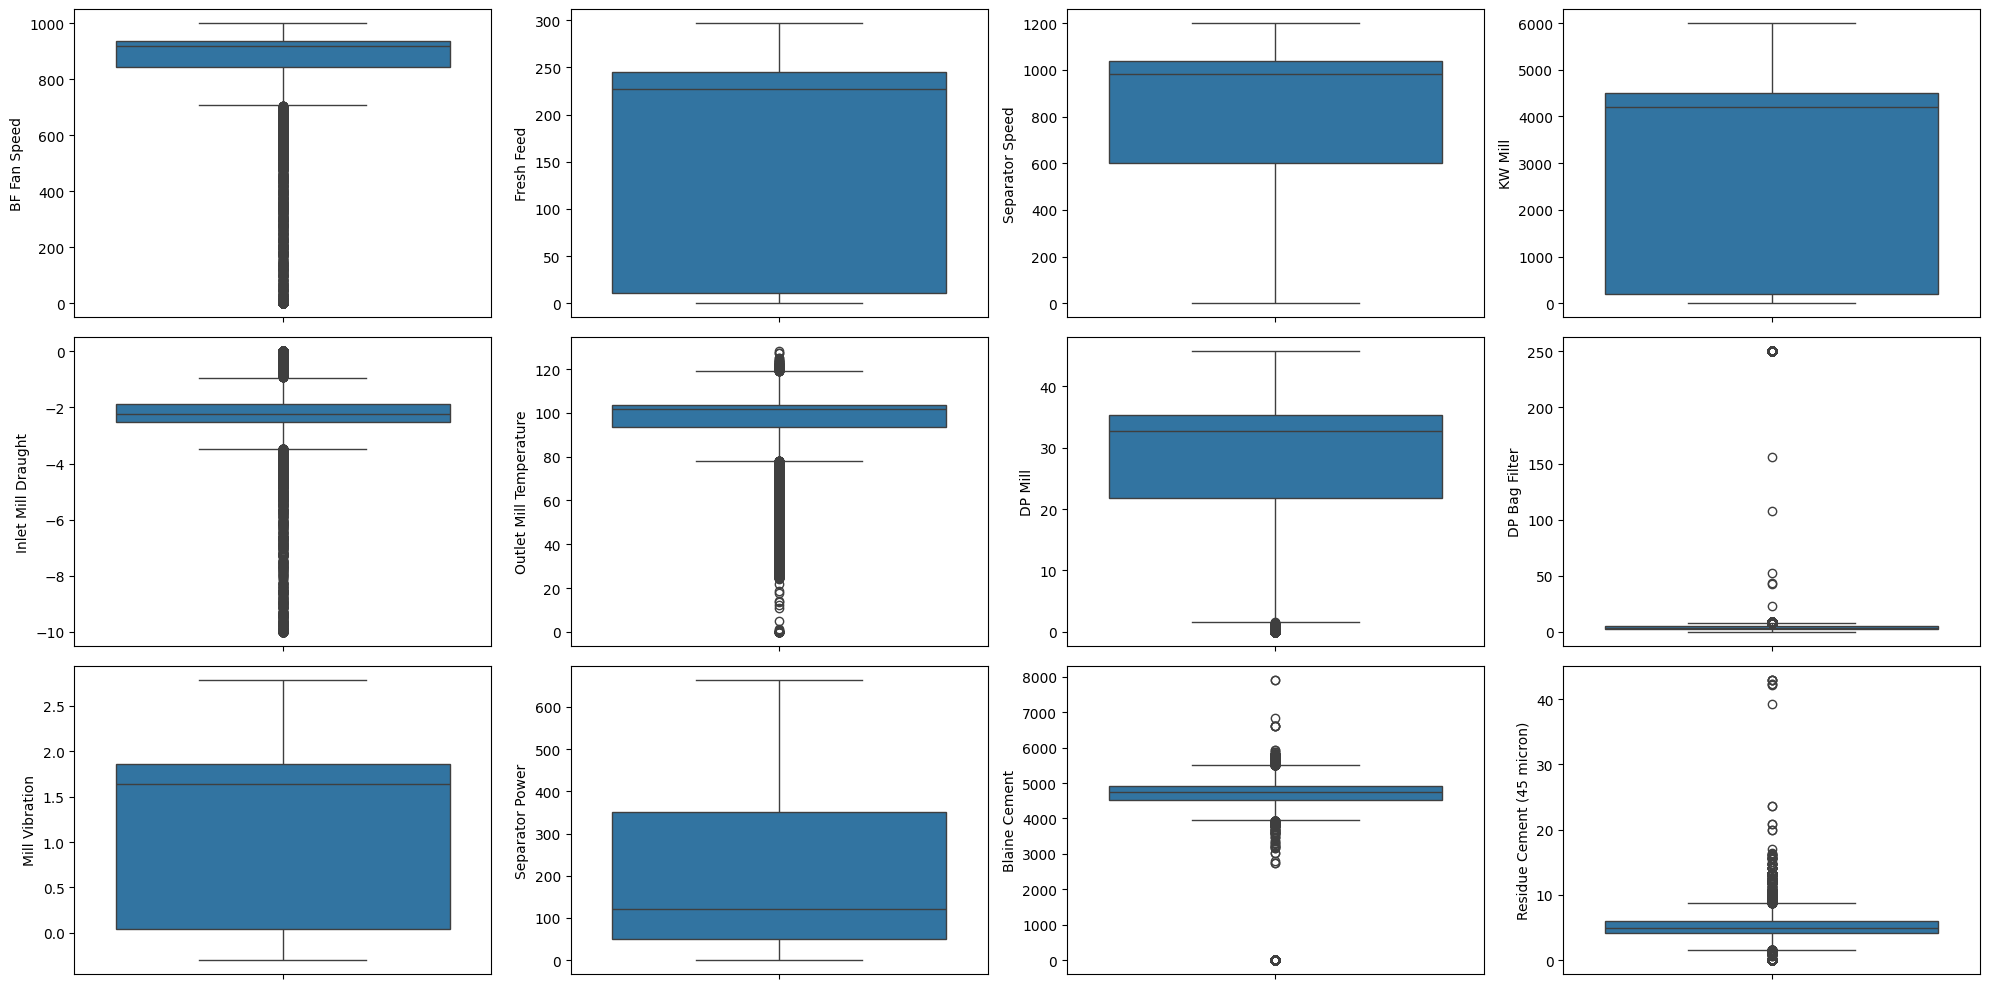

In [ ]:
semua_kolom=['BF Fan Speed', 'Fresh Feed', 'Separator Speed', 'KW Mill', 'Inlet Mill Draught', 'Outlet Mill Temperature', 'DP Mill', 'DP Bag Filter', 'Mill Vibration', 'Separator Power', 'Blaine Cement', 'Residue Cement (45 micron)']

plt.figure(figsize=(20, 10))
for i in range(0, len(semua_kolom)):
  plt.subplot(3, 4, i+1)
  sns.boxplot(y = df[semua_kolom[i]])
  plt.tight_layout()

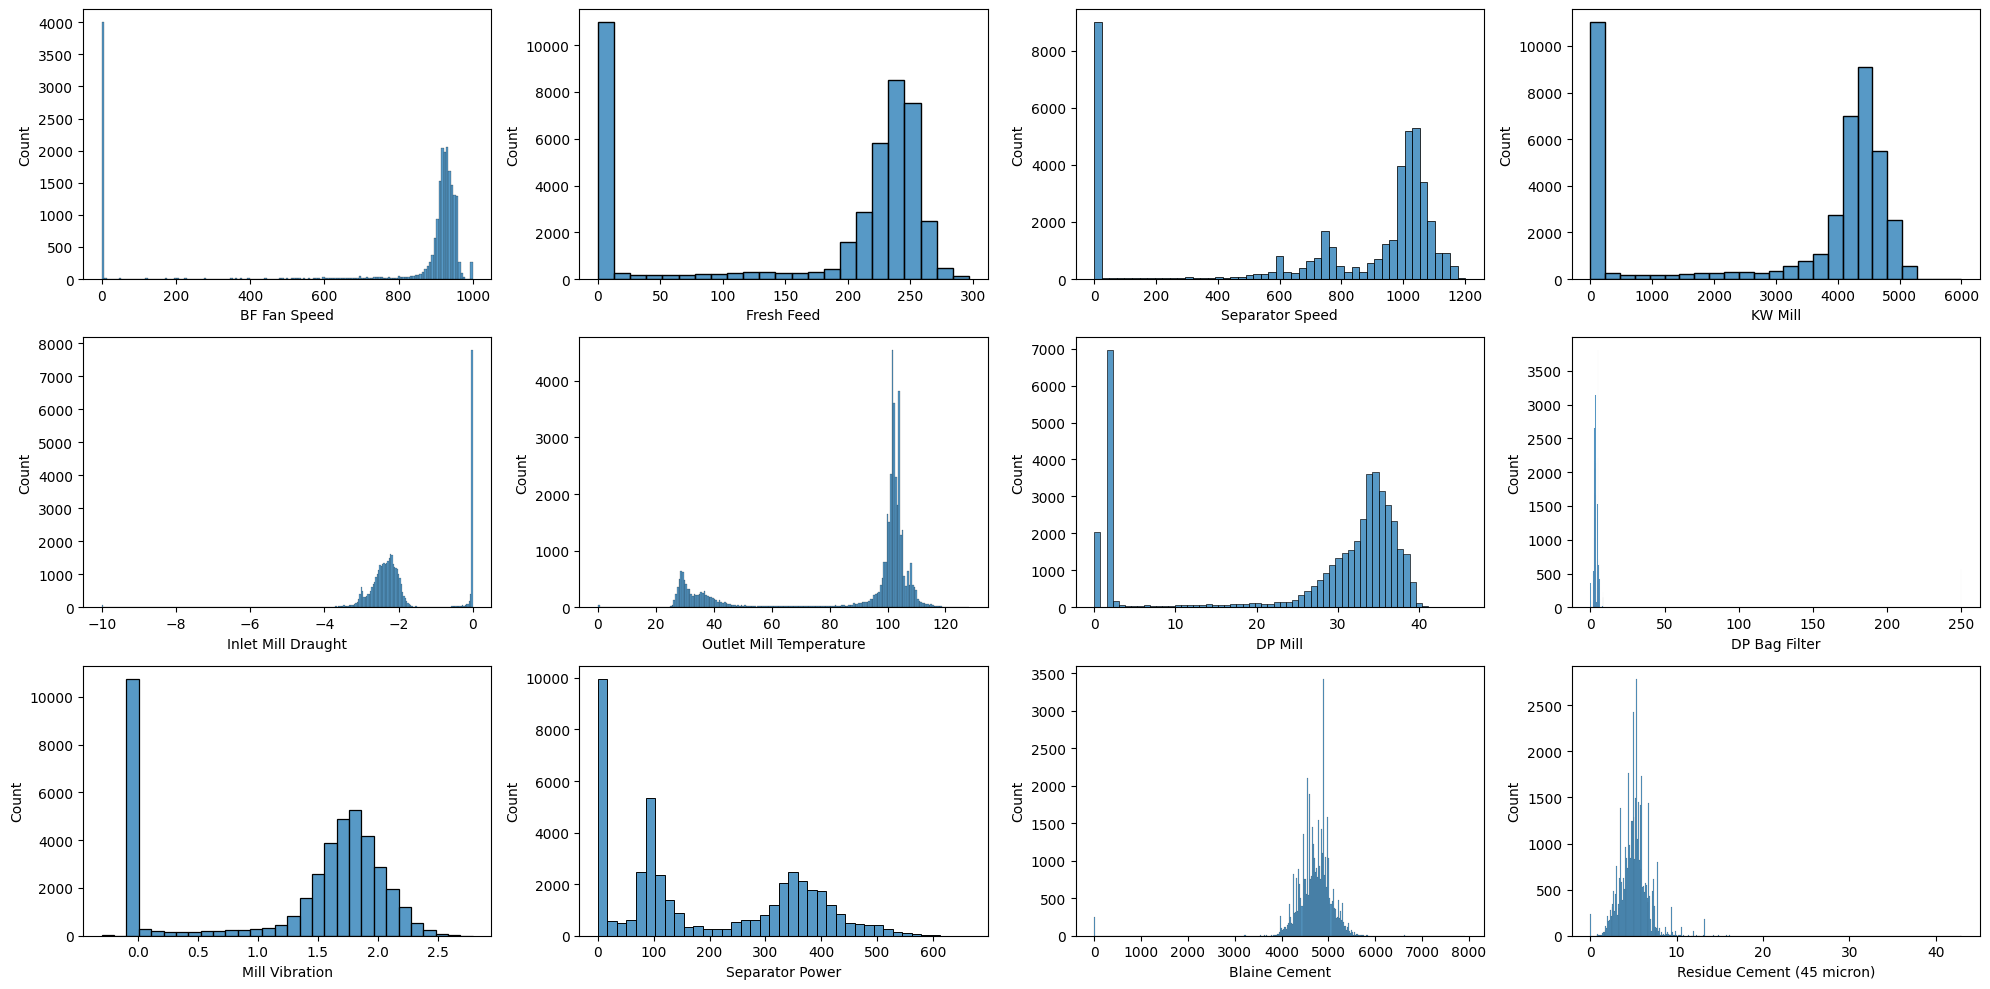

In [ ]:
plt.figure(figsize=(20, 10))
for i in range(0, len(semua_kolom)):
  plt.subplot(3, 4, i+1)
  sns.histplot(df[semua_kolom[i]])
  plt.tight_layout()

Rasio Outlier

In [ ]:
for kolom in semua_kolom:
  Q1 = df[kolom].quantile(0.25)
  Q3 = df[kolom].quantile(0.75)
  IQR = Q3 - Q1

  outlier_ratio = (
    ((df[kolom] < Q1 - 1.5*IQR) |
     (df[kolom] > Q3 + 1.5*IQR))
    .mean()
    )
  print(f"Rasio outlier {kolom}:", outlier_ratio)


Rasio outlier BF Fan Speed: 0.11458119306896788
Rasio outlier Fresh Feed: 0.0
Rasio outlier Separator Speed: 0.0
Rasio outlier KW Mill: 0.0
Rasio outlier Inlet Mill Draught: 0.2360568910805196
Rasio outlier Outlet Mill Temperature: 0.22112640686710955
Rasio outlier DP Mill: 0.047234207702668764
Rasio outlier DP Bag Filter: 0.029518526128347374
Rasio outlier Mill Vibration: 0.0
Rasio outlier Separator Power: 0.0
Rasio outlier Blaine Cement: 0.014976143186539734
Rasio outlier Residue Cement (45 micron): 0.030888295322238205


In [ ]:
for kolom in semua_kolom:
  Q1e = np.quantile(df[kolom], 0.25)
  Q2 = np.quantile(df[kolom], 0.5)
  Q3e = np.quantile(df[kolom], 0.75)
  MAX = np.quantile(df[kolom], 1)
  print(f"Nilai Q1 {kolom}:", Q1e)
  print(f"Nilai Q2 {kolom}:", Q2)
  print(f"Nilai Q3 {kolom}:", Q3e)
  print(f"Nilai MAX {kolom}:", MAX)

Nilai Q1 BF Fan Speed: nan
Nilai Q2 BF Fan Speed: nan
Nilai Q3 BF Fan Speed: nan
Nilai MAX BF Fan Speed: nan
Nilai Q1 Fresh Feed: 11.3335
Nilai Q2 Fresh Feed: 226.692
Nilai Q3 Fresh Feed: 244.9345
Nilai MAX Fresh Feed: 296.867
Nilai Q1 Separator Speed: 599.908
Nilai Q2 Separator Speed: 979.927
Nilai Q3 Separator Speed: 1039.473
Nilai MAX Separator Speed: 1200.242
Nilai Q1 KW Mill: 191.59300000000002
Nilai Q2 KW Mill: 4193.053
Nilai Q3 KW Mill: 4492.793
Nilai MAX KW Mill: 6000.0
Nilai Q1 Inlet Mill Draught: -2.525
Nilai Q2 Inlet Mill Draught: -2.232
Nilai Q3 Inlet Mill Draught: -1.889
Nilai MAX Inlet Mill Draught: 0.0
Nilai Q1 Outlet Mill Temperature: 93.56899999999999
Nilai Q2 Outlet Mill Temperature: 101.8
Nilai Q3 Outlet Mill Temperature: 103.818
Nilai MAX Outlet Mill Temperature: 128.123
Nilai Q1 DP Mill: 21.8125
Nilai Q2 DP Mill: 32.738
Nilai Q3 DP Mill: 35.325
Nilai MAX DP Mill: 45.718
Nilai Q1 DP Bag Filter: 2.779
Nilai Q2 DP Bag Filter: 3.428
Nilai Q3 DP Bag Filter: 4.827
Nilai 

#**Cek Skewness**
(Kemencengan
| ≈ 0   | Simetris              |
| > 0   | Ekor panjang ke kanan |
| < 0   | Ekor panjang ke kiri  |
) dan

#**Kurtosis**
(Ketajaman Puncak
| ≈ 3   | Normal           |
| > 5   | Banyak outlier   |
| < 3   | Distribusi datar |
)
*   Inlet Mill Draught (Ekstrem)
*   DP Bag Filter (Terlalu Ekstrem)



In [ ]:
for kolom in semua_kolom:
  df[kolom].skew(), df[kolom].kurt()
  print(f"Skewness {kolom}:", df[kolom].skew())
  print(f"Kurtosis {kolom}:", df[kolom].kurt())


Skewness BF Fan Speed: -1.465703526969078
Kurtosis BF Fan Speed: 0.26442700221961024
Skewness Fresh Feed: -0.8539861421346251
Kurtosis Fresh Feed: -1.101544165170867
Skewness Separator Speed: -1.0416467628002615
Kurtosis Separator Speed: -0.5834958619873301
Skewness KW Mill: -0.8385751554110538
Kurtosis KW Mill: -1.1183549656274376
Skewness Inlet Mill Draught: -0.8625826823393948
Kurtosis Inlet Mill Draught: 7.4001834708253575
Skewness Outlet Mill Temperature: -1.3920985115161677
Kurtosis Outlet Mill Temperature: 0.15375991010267454
Skewness DP Mill: -1.0833859513060882
Kurtosis DP Mill: -0.5539504954363914
Skewness DP Bag Filter: 8.53827222825111
Kurtosis DP Bag Filter: 71.10665139995763
Skewness Mill Vibration: -0.7404445503064273
Kurtosis Mill Vibration: -1.1024284436315321
Skewness Separator Power: 0.3348073697276634
Kurtosis Separator Power: -1.3416618277796635
Skewness Blaine Cement: -5.638620764855211
Kurtosis Blaine Cement: 54.82648711212714
Skewness Residue Cement (45 micron):

#Cek Korelasi

In [ ]:
for kolom in semua_kolom:
  df.corr()[kolom].sort_values(ascending=False)
  print(f"Korelasi {kolom}:",
        df.corr()[kolom].sort_values(ascending=False))

Korelasi BF Fan Speed: BF Fan Speed                  1.000000
DP Mill                       0.946750
Separator Speed               0.879871
Outlet Mill Temperature       0.862352
Fresh Feed                    0.859717
KW Mill                       0.852368
Mill Vibration                0.839800
Separator Power               0.807696
Blaine Cement                 0.129129
Date and Time                -0.091376
Residue Cement (45 micron)   -0.141061
DP Bag Filter                -0.336188
Inlet Mill Draught           -0.685592
Name: BF Fan Speed, dtype: float64
Korelasi Fresh Feed: Fresh Feed                    1.000000
KW Mill                       0.986765
Mill Vibration                0.951685
DP Mill                       0.939509
Separator Speed               0.890030
BF Fan Speed                  0.859717
Outlet Mill Temperature       0.832299
Separator Power               0.703273
Blaine Cement                 0.130428
Date and Time                 0.010139
Residue Cement (45 micro

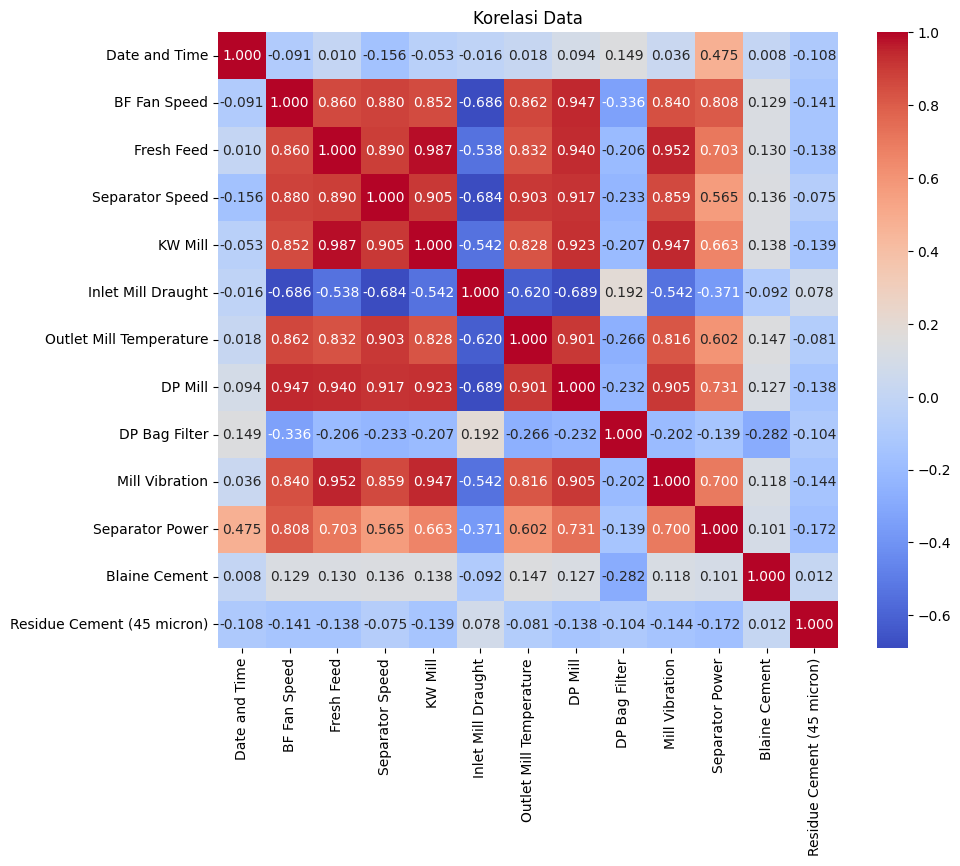

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, fmt=".3f", cmap="coolwarm")
plt.title(f"Korelasi Data")
plt.show()

<Axes: xlabel='BF Fan Speed', ylabel='KW Mill'>

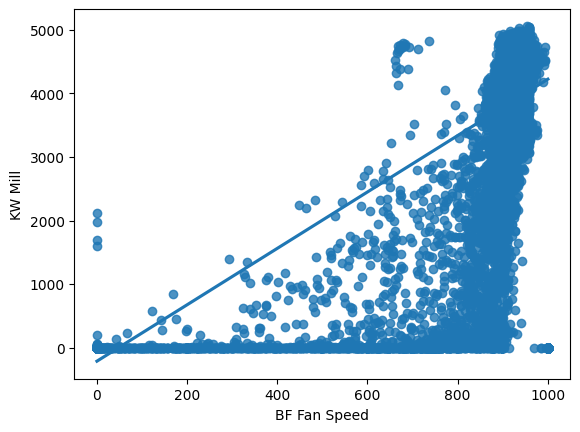

In [ ]:
sns.regplot(x=df['BF Fan Speed'], y=df['KW Mill'])

<Axes: xlabel='Fresh Feed', ylabel='Residue Cement (45 micron)'>

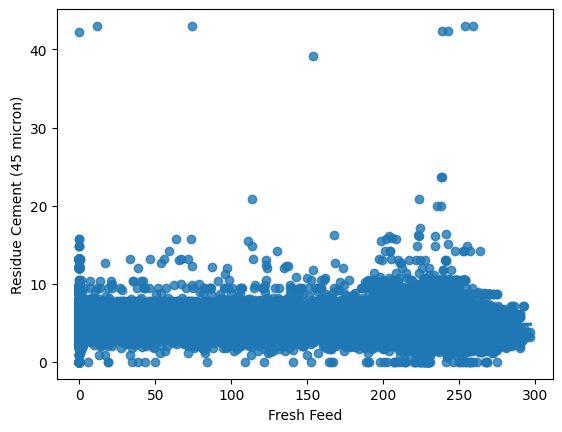

In [ ]:
sns.regplot(x=df['Fresh Feed'], y=df['Residue Cement (45 micron)'])

**Data belum ok** masih banyak outlier,
**DP Bag Filter, Inlet Mill Draught, Blaine, dan Residue 45 micron** data masih kurang layak
* DP Bag Filter: Skewness, Kurtosis, dan Korelasi nya jelek
* Inlet Mill Draught: Kurtosis besar (banyak outlier)
* Blaine: Kurtosis besar
* Residue 45 Micron: Kurtosis besar

Perlu modifikasi lebih besar lagi
Data yang benar2 sehat hanya 5 data, yang lain masih banyak outlier

Langkah Modifikasi
1. Harus menghilangkan outlier terlebih dahulu
2. Melakukan normalisasi pada seluruh kolom

*   Outlet Mill Temperature tidak mungkin kurang dari 90 (Untuk data yang kurang dari 90 dianggap mill mati)
*   Inlet Mill Draught Tidak usah dilakukan modifikasi



#COBA TRANSFORMASI DATA

In [ ]:
pt = PowerTransformer(method='yeo-johnson')
df['DP Mill'] = pt.fit_transform(df['DP Mill'].values.reshape(-1, 1))

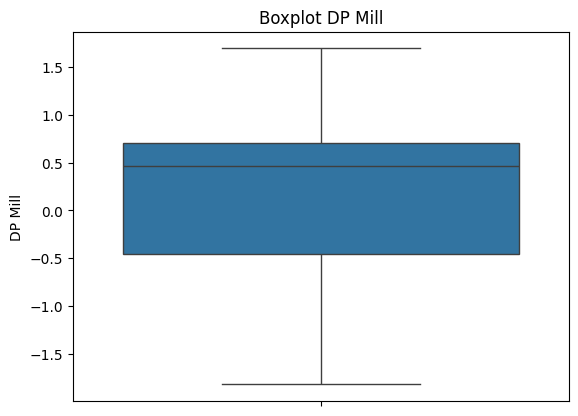

In [ ]:
sns.boxplot(df['DP Mill'])
plt.title("Boxplot DP Mill")
plt.show()

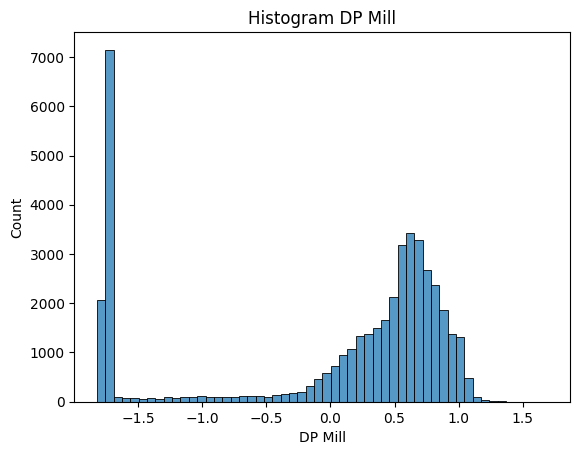

In [ ]:
sns.histplot(df['DP Mill'])
plt.title("Histogram DP Mill")
plt.show()

In [ ]:
Q1 = df['DP Mill'].quantile(0.25)
Q3 = df['DP Mill'].quantile(0.75)
IQR = Q3 - Q1

outlier_ratio_dp_mill = (
    ((df['DP Mill'] < Q1 - 1.5*IQR) |
     (df['DP Mill'] > Q3 + 1.5*IQR))
    .mean()
    )
print(f"Rasio outlier DP Mill:", outlier_ratio_dp_mill)

Rasio outlier DP Mill: 0.0


In [ ]:
for kolom in semua_kolom:
  df[kolom].skew(), df[kolom].kurt()
  print(f"Skewness {kolom}:", df[kolom].skew())
  print(f"Kurtosis {kolom}:", df[kolom].kurt())


Skewness BF Fan Speed: -1.465703526969078
Kurtosis BF Fan Speed: 0.26442700221961024
Skewness Fresh Feed: -0.8539861421346251
Kurtosis Fresh Feed: -1.101544165170867
Skewness Separator Speed: -1.0416467628002615
Kurtosis Separator Speed: -0.5834958619873301
Skewness KW Mill: -0.8385751554110538
Kurtosis KW Mill: -1.1183549656274376
Skewness Inlet Mill Draught: -0.8625826823393948
Kurtosis Inlet Mill Draught: 7.4001834708253575
Skewness Outlet Mill Temperature: -1.3920985115161677
Kurtosis Outlet Mill Temperature: 0.15375991010267454
Skewness DP Mill: -0.9876234654695824
Kurtosis DP Mill: -0.6897314099011056
Skewness DP Bag Filter: 8.53827222825111
Kurtosis DP Bag Filter: 71.10665139995763
Skewness Mill Vibration: -0.7404445503064273
Kurtosis Mill Vibration: -1.1024284436315321
Skewness Separator Power: 0.3348073697276634
Kurtosis Separator Power: -1.3416618277796635
Skewness Blaine Cement: -5.638620764855211
Kurtosis Blaine Cement: 54.82648711212714
Skewness Residue Cement (45 micron):

In [ ]:
for kolom in semua_kolom:
  Q1 = df[kolom].quantile(0.25)
  Q3 = df[kolom].quantile(0.75)
  IQR = Q3 - Q1

  outlier_ratio = (
    ((df[kolom] < Q1 - 1.5*IQR) |
     (df[kolom] > Q3 + 1.5*IQR))
    .mean()
    )
  print(f"Rasio outlier {kolom}:", outlier_ratio)


Rasio outlier BF Fan Speed: 0.11458119306896788
Rasio outlier Fresh Feed: 0.0
Rasio outlier Separator Speed: 0.0
Rasio outlier KW Mill: 0.0
Rasio outlier Inlet Mill Draught: 0.2360568910805196
Rasio outlier Outlet Mill Temperature: 0.22112640686710955
Rasio outlier DP Mill: 0.0
Rasio outlier DP Bag Filter: 0.029518526128347374
Rasio outlier Mill Vibration: 0.0
Rasio outlier Separator Power: 0.0
Rasio outlier Blaine Cement: 0.014976143186539734
Rasio outlier Residue Cement (45 micron): 0.030888295322238205


Kurva Distribusi Nilai

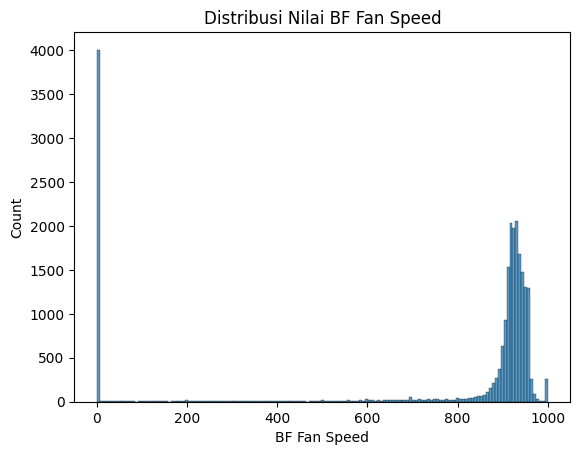

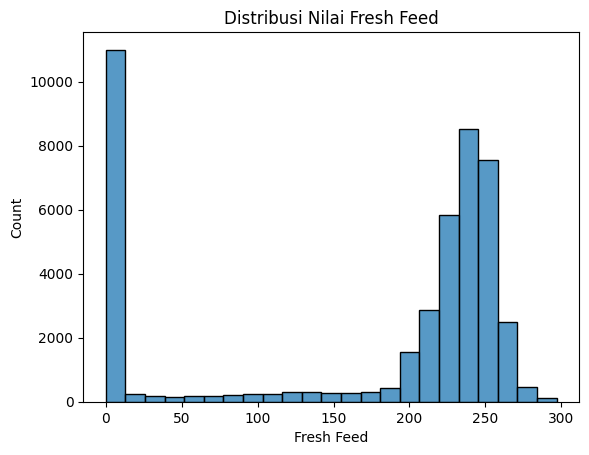

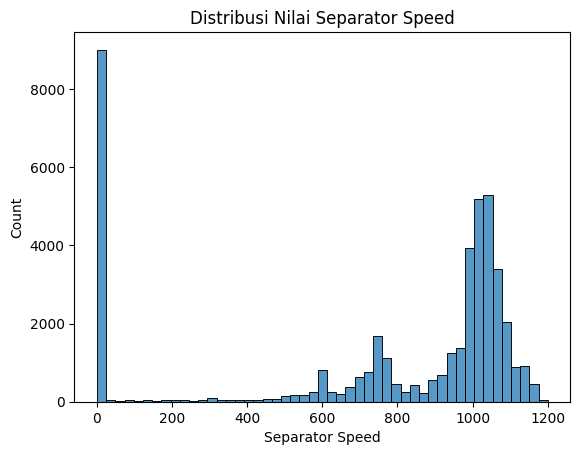

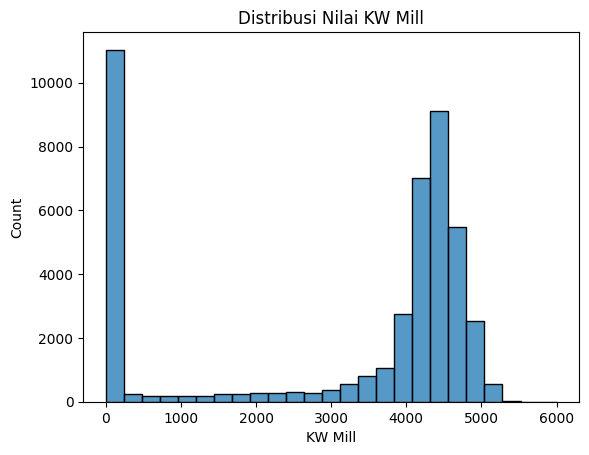

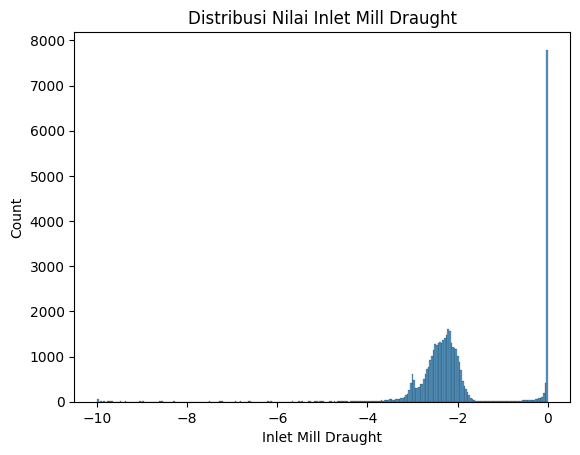

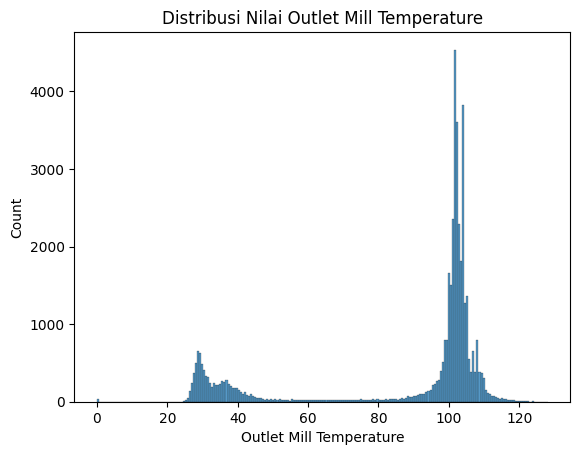

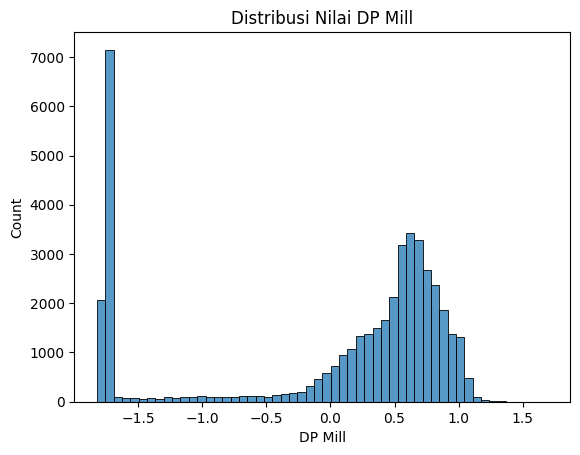

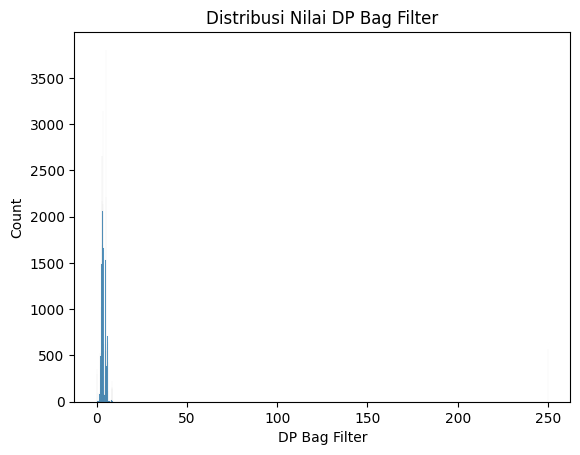

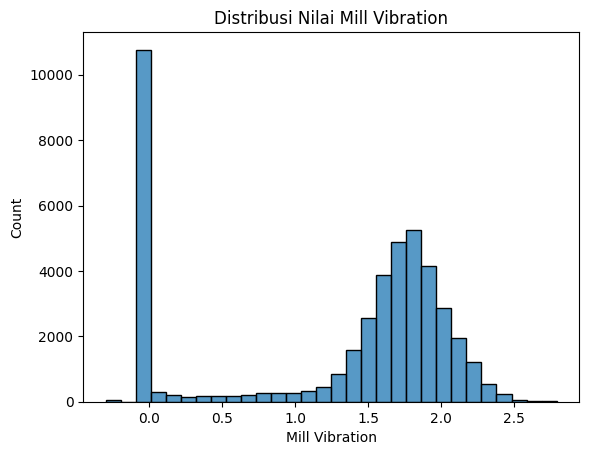

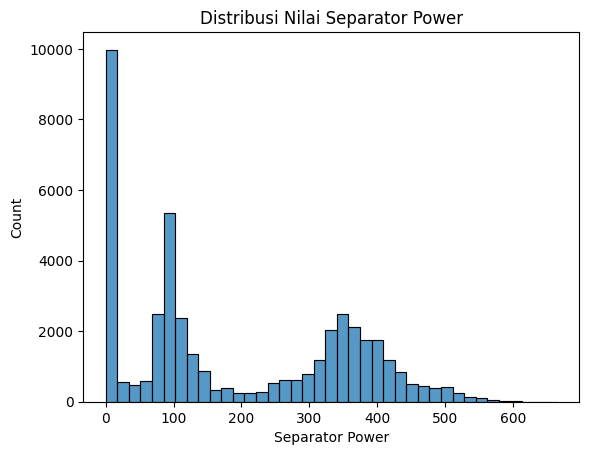

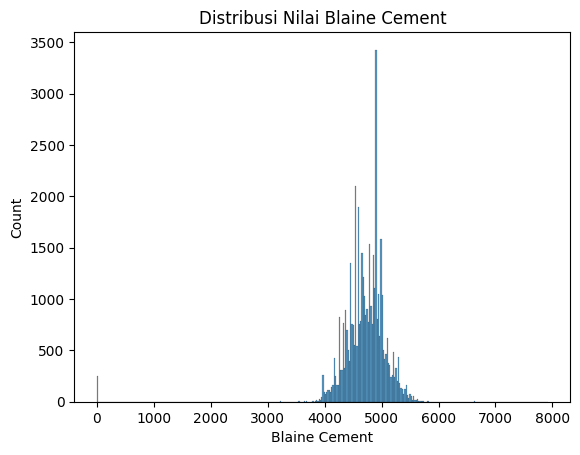

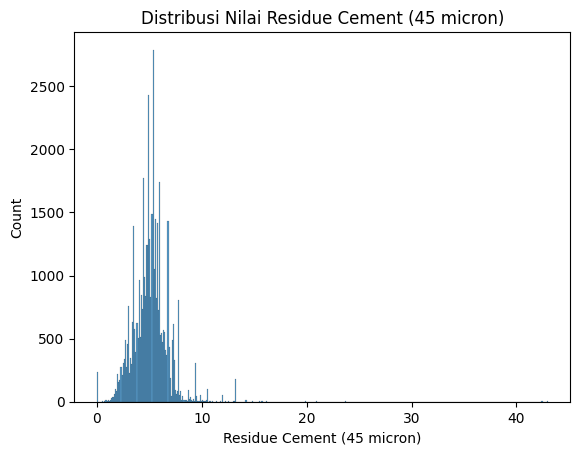

In [ ]:
for kolom in semua_kolom:
    plt.figure()
    sns.histplot(df[kolom])
    plt.title(f"Distribusi Nilai {kolom}")
    plt.show()

Uji Normalisasi (Apakah Perlu?) Selama data layak, data tidak perlu normal (Terutama untuk Training AI)

In [ ]:
for kolom in semua_kolom:
  stat, p = shapiro(df[kolom])
  print(f"p-value {kolom}: ", p)

  if p > 0.05:
    print("Data Terdistribusi Normal")
  else:
    print("Data Tidak Terdistribusi Normal")

p-value BF Fan Speed:  nan
Data Tidak Terdistribusi Normal
p-value Fresh Feed:  3.6675047855572243e-121
Data Tidak Terdistribusi Normal
p-value Separator Speed:  4.0307931152648694e-119
Data Tidak Terdistribusi Normal
p-value KW Mill:  1.4337139727980665e-120
Data Tidak Terdistribusi Normal
p-value Inlet Mill Draught:  1.7965906223176568e-115
Data Tidak Terdistribusi Normal
p-value Outlet Mill Temperature:  1.763844325858483e-127
Data Tidak Terdistribusi Normal
p-value DP Mill:  2.4185334651527894e-116
Data Tidak Terdistribusi Normal
p-value DP Bag Filter:  8.562139564421813e-156
Data Tidak Terdistribusi Normal
p-value Mill Vibration:  2.2040166265158424e-112
Data Tidak Terdistribusi Normal
p-value Separator Power:  1.896318959584863e-97
Data Tidak Terdistribusi Normal
p-value Blaine Cement:  9.94458751144507e-129
Data Tidak Terdistribusi Normal
p-value Residue Cement (45 micron):  9.46729759092588e-97
Data Tidak Terdistribusi Normal


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 43803.
  res = hypotest_fun_out(*samples, **kwds)


(Coba/Bisa Skip) Transformasi Data
- (cara logaritmik masih jelek)
- (cara standardscaler masih jelek)

In [ ]:
for kolom in semua_kolom:
  scaler = StandardScaler()
  df[kolom] = scaler.fit_transform(df[kolom].values.reshape(-1, 1))

NameError: name 'StandardScaler' is not defined

In [ ]:
for kolom in semua_kolom:
  sns.histplot(df[kolom])
  plt.title(f"Distribusi Nilai {kolom} Setelah Transformasi")
  plt.show()

Dengan Logaritmik, 7 dari 10 data sudah terdistribusi normal

In [ ]:
for kolom in semua_kolom:
  stat, p = shapiro(df[kolom])
  print(f"p-value {kolom}: ", p)

  if p > 0.05:
    print(f"Data {kolom} Terdistribusi Normal")
  else:
    print(f"Data {kolom} Tidak Terdistribusi Normal")

In [ ]:
for kolom in semua_kolom:
    plt.figure()
    sns.boxplot(df[kolom])
    plt.title(f"Boxplot {kolom}")
    plt.ylabel(kolom)
    plt.show()